# Exam 16th of January 2026, 8.00-13.00 for the course 1MS041 (Introduction to Data Science / Introduktion till dataanalys)

## Instructions:
1. Complete the problems by following instructions.
2. When done, submit this file with your solutions saved, following the instruction sheet.

This exam has 3 problems for a total of 40 points, to pass you need
20 points. The bonus will be added to the score of the exam and rounded afterwards.

## Some general hints and information:
* Try to answer all questions even if you are uncertain.
* Comment your code, so that if you get the wrong answer I can understand how you thought
this can give you some points even though the code does not run.
* Follow the instruction sheet rigorously.
* This exam is partially autograded, but your code and your free text answers are manually graded anonymously.
* If there are any questions, please ask the exam guards, they will escalate it to me if necessary.

## Tips for free text answers
* Be VERY clear with your reasoning, there should be zero ambiguity in what you are referring to.
* If you want to include math, you can write LaTeX in the Markdown cells, for instance `$f(x)=x^2$` will be rendered as $f(x)=x^2$ and `$$f(x) = x^2$$` will become an equation line, as follows
$$f(x) = x^2$$
Another example is `$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$` which renders as
$$f_{Y \mid X}(y,x) = P(Y = y \mid X = x) = \exp(\alpha \cdot x + \beta)$$

## Finally some rules:
* You may not communicate with others during the exam, for example:
    * You cannot ask for help in Stack-Overflow or other such help forums during the Exam.
    * You may not communicate with AI's, for instance ChatGPT.
    * Your on-line and off-line activity is being monitored according to the examination rules.

## Good luck!

In [ ]:
# Insert your anonymous exam ID as a string in the variable below
examID=0044-WFT


---
## Exam vB, PROBLEM 1
Maximum Points = 14


This problem is about **SVD** and a simple **anomaly detection** idea using low-rank reconstruction.



Unless stated otherwise, when you are asked to produce a matrix or vector, it must be a **NumPy array**.

1. **[4p] SVD.** Load `data/SVD.csv` as instructed in the code cell. Let $X$ be the data matrix of shape `n_samples × n_dimensions`. Compute an SVD
   $$X = U D V^T$$
   where $U$ has shape `n_samples × n_dimensions`, $D$ is the diagonal matrix of shape `(n_dimensions,n_dimensions)` that has the singular values on the diagonal (see documentation for `np.diag`), and $V$ has shape `n_dimensions × n_dimensions`.
   **Important:** `np.linalg.svd` returns `U, d, Vt` where `Vt` is $V^T$.
   Also extract the **first** right and left singular vectors and store them as 1D arrays in the variables provided.

2. **[3p] Explained variance.** For $N =$ `n_dimensions`, define the explained variance using the first $k$ singular values as
   $$
   \mathrm{EV}(k) = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^N \sigma_i^2}.
   $$
   Compute $\mathrm{EV}(k)$ for $k=1,2,\dots,N$ and store it in `problem1_explained_variance` (length `N`). Then set `problem1_num_components` to the **smallest** $k$ such that $\mathrm{EV}(k) \ge 0.99$.

3. **[3p] Plot + interpretation.** Plot explained variance (x-axis: number of components $k$, y-axis: $\mathrm{EV}(k)$). In the markdown cell below, reason about the shape of the curve for this dataset.

4. **[4p] Low-rank reconstruction + outliers.**
   - Using `problem1_num_components`, construct the best rank-$k$ approximation of $X$ and store it in `problem1_approximation`.
   - Compute the row-wise Euclidean reconstruction error $\|X_i - \hat X_i\|_2$ for each row $i$ and store it in `problem1_reconstruction_error` (shape `(n_samples,)`).
   - Plot the empirical distribution function (EDF) of the reconstruction errors (you may use `makeEDF` / `plotEDF` from `Utils.py`).
   - Choose a threshold `problem1_threshold` so that **exactly 100** samples are flagged as outliers (i.e. have reconstruction error >= the threshold).
   - Store those flagged rows in `problem1_outliers` (shape `(100, n_dimensions)`).


In [ ]:
import os

# Search for SVD.csv inside Downloads
for root, dirs, files in os.walk(os.getcwd()):
    if "SVD.csv" in files:
        print(os.path.join(root, "SVD.csv"))

In [3]:
%pip install pandas

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 6.0 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.8 MB 6.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.8 MB 6.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.8 MB 6.3 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 6.1 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.8 MB 5.8 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 5.6 MB/s  0:00:01

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------------------------

In [7]:
# Part 1: 4 points

# Load the data from the file data/SVD.csv and store the data in a numpy array called problem1_data below
# Double check that the numbers have been parsed correctly by checking the dtype of the array by calling problem1_data.dtype

# Part 1: 4 points


import numpy as np
import pandas as pd

# Load CSV data
problem1_data = pd.read_csv('SVD.csv').to_numpy()

# Check dtype and shape
print(problem1_data.dtype)
print(problem1_data.shape)

# SVD
U, d, Vt = np.linalg.svd(problem1_data, full_matrices=False)

problem1_U = U
problem1_D = np.diag(d)
problem1_V = Vt.T

problem1_first_right_singular_vector = Vt[0, :].flatten()
problem1_first_left_singular_vector = U[:, 0].flatten()


float64
(1009, 100)


In [8]:
# Part 2: 3 points

# Calculate the explained variance of using 1,2,3,...,n_dimensions singular values and store it as a numpy array called problem1_explained_variance below
singular_values = np.diag(problem1_D)
problem1_explained_variance = np.cumsum(singular_values**2) / np.sum(singular_values**2) # A numpy array of shape (n_dimensions,), it should be an increasing sequence of positive numbers and the last element should be 1

# Store in the variable below the smallest number of singular values needed to explain at least 99% of the variance
problem1_num_components = int(np.searchsorted(problem1_explained_variance, 0.99) + 1)

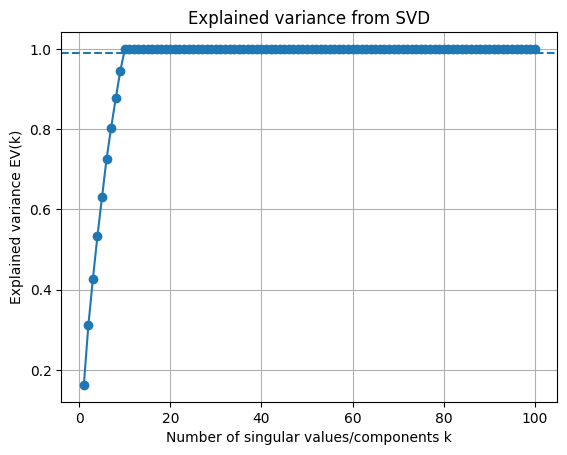

In [9]:
# Part 3: 3 points

# Put the code below to plot the explained variance
# use for instance matplotlib

import matplotlib.pyplot as plt

ks = np.arange(1, len(problem1_explained_variance) + 1)

plt.plot(ks, problem1_explained_variance, marker='o')
plt.axhline(0.99, linestyle='--')
plt.xlabel("Number of singular values/components k")
plt.ylabel("Explained variance EV(k)")
plt.title("Explained variance from SVD")
plt.grid(True)
plt.show()





## Free-text answer (Part 3)



In 2–5 sentences:



- Describe the *shape* of the explained-variance curve.

- Explain why it looks like that for this dataset.



Write your explanation below this line.


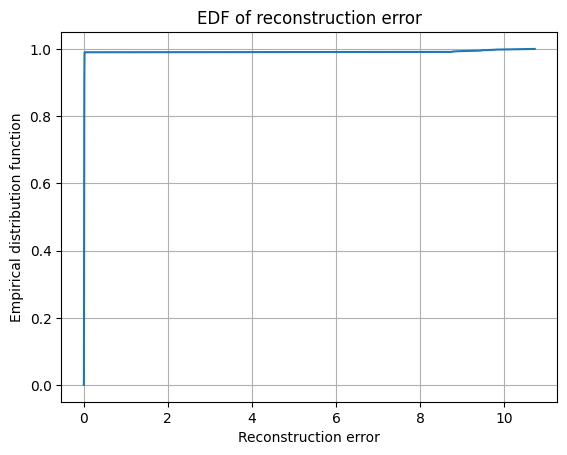

In [10]:
# Part 4: 4 points

# Calculate the approximating matrix of problem1_data using the first problem1_num_components singular values and store it in the variable bel
k = problem1_num_components

problem1_approximation = problem1_U[:, :k] @ problem1_D[:k, :k] @ problem1_V[:, :k].T # A numpy array of shape n_samples x n_dimensions

# Calculate the reconstruction error of problem1_data using problem1_approximation and store it in the variable below (should have shape (n_samples,)) (row wise Euclidean distance)
problem1_reconstruction_error = np.linalg.norm(problem1_data - problem1_approximation, axis=1)

# Put the code below to plot the empirical distribution function of the reconstruction error
# You can use the Utils.py file for plotting the empirical distribution function, makeEDF and plotEDF functions
try:
    from Utils import makeEDF, plotEDF
    x_edf, y_edf = makeEDF(problem1_reconstruction_error)
    plotEDF(x_edf, y_edf)
except Exception:
    sorted_errors = np.sort(problem1_reconstruction_error)
    edf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
    plt.plot(sorted_errors, edf)
    plt.xlabel("Reconstruction error")
    plt.ylabel("Empirical distribution function")
    plt.title("EDF of reconstruction error")
    plt.grid(True)
    plt.show()
# Select the 100 largest reconstruction errors as outliers.
# A threshold just below the 100th largest error makes those 100 points exceed the threshold.
sorted_errors = np.sort(problem1_reconstruction_error)
# Store the value of the selected threshold in the variable below
problem1_threshold = np.nextafter(sorted_errors[-100], -np.inf)

problem1_outliers = problem1_data[problem1_reconstruction_error > problem1_threshold]


# Finally store the samples of problem1_data that have a reconstruction error larger than problem1_threshold in the variable below, should have shape (100, n_dimensions)
# Safety fallback in case there are exact ties causing more/less than 100 rows
if problem1_outliers.shape[0] != 100:
    outlier_indices = np.argsort(problem1_reconstruction_error)[-100:]
    problem1_outliers = problem1_data[outlier_indices]

---
## Exam vB, PROBLEM 2
Maximum Points = 12


In this problem we are interested in **account takeover (ATO) detection** for an online service. You are given the outputs of a classifier that predicts the probability that a login attempt is malicious ($Y=1$). Your goal is to explore how the **decision threshold** affects business cost (as in the thresholding assignment).

A threshold $t \in [0,1]$ is used to convert predicted probabilities $\hat p(x)=P(Y=1\mid x)$ to labels: predict $\hat y=1$ if $\hat p(x)\ge t$, else $\hat y=0$.

The costs associated with the decisions are:

* **True Positive (TP)**: correctly flagging an ATO login costs **80** (extra verification + friction).
* **True Negative (TN)**: allowing a legitimate login has **0** cost.
* **False Positive (FP)**: incorrectly flagging a legitimate login costs **150** (support load + churn risk).
* **False Negative (FN)**: missing an ATO login costs **900** (fraud + remediation).

**The code cells contain more detailed instructions; THE FIRST CODE CELL INITIALIZES YOUR VARIABLES.**

1. **[3p]** Complete the function `problem2_avg_cost` to compute the **average cost per sample** of a model under a certain prediction threshold. Plot the cost as a function of the threshold (using the validation data provided in the first code cell of this problem), from 0 to 1 with step size 0.01.
2. **[2.5p]** Find the threshold that minimizes the cost and calculate the cost at that threshold on the validation data. Also calculate the precision and recall at the optimal threshold, treating **class 1 as the positive class** and **class 0 as the positive class** separately.
3. **[2.5p]** Repeat step 2, but this time find the best threshold to **maximize accuracy** (equivalently, minimize the $0{-}1$ loss). Calculate the difference in cost between the threshold found in part 3 and the one found in part 2.
4. **[4p]** Provide a confidence interval around the optimal cost (with $95\%$ confidence) applied to the test data using **Hoeffding's inequality**, and explain all assumptions you made.

In [17]:
import os

for root, dirs, files in os.walk(r"C:\Users\hp\Downloads"):
    if "Utils.py" in files:
        print(os.path.join(root, "Utils.py"))

In [19]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 7.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.2 MB 8.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 8.6 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 7.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 6.7 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.5 MB 8.5 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/36.5 MB 8.7 MB/s eta 0:00:04
   ----- ---------------------------------- 5.2/36.5 MB 8.8 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/36.5 MB 8.8 MB/s eta 0:00:04
   --------- ------------------------------ 8.9/36.5 MB 8.8 MB/s eta 0:00:04
   ----------- --------

In [20]:
# RUN THIS CELL TO GET THE DATA

import pandas as pd
import numpy as np

PROBLEM2_DF = pd.read_csv(r"C:\Users\hp\Downloads\DATA SCIENCE\fraud.csv")

Y = PROBLEM2_DF['Class'].values
X = PROBLEM2_DF[['V%d' % i for i in range(1, 5)] + ['Amount']].values


# We will split the data into training, testing and validation sets
from sklearn.model_selection import train_test_split

PROBLEM2_X_train, X_temp, PROBLEM2_y_train, y_temp = train_test_split(
    X,
    Y,
    test_size=0.4,
    shuffle=True,
    random_state=1,
    stratify=Y
)

PROBLEM2_X_test, PROBLEM2_X_val, PROBLEM2_y_test, PROBLEM2_y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    shuffle=True,
    random_state=1,
    stratify=y_temp
)


# From this we will train a logistic regression model with scaling and simple hyperparameter search
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=1))
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
gs.fit(PROBLEM2_X_train, PROBLEM2_y_train)

# use the best pipeline (it supports predict_proba)
lr = gs.best_estimator_

# THE FOLLOWING CODE WILL PRODUCE THE ARRAYS YOU NEED FOR THE PROBLEM
PROBLEM2_y_pred_proba_val = lr.predict_proba(PROBLEM2_X_val)[:, 1]
PROBLEM2_y_true_val = PROBLEM2_y_val

PROBLEM2_y_pred_proba_test = lr.predict_proba(PROBLEM2_X_test)[:, 1]
PROBLEM2_y_true_test = PROBLEM2_y_test

print("Done")
print("Train:", PROBLEM2_X_train.shape)
print("Test:", PROBLEM2_X_test.shape)
print("Validation:", PROBLEM2_X_val.shape)

Done
Train: (3194, 5)
Test: (1065, 5)
Validation: (1065, 5)


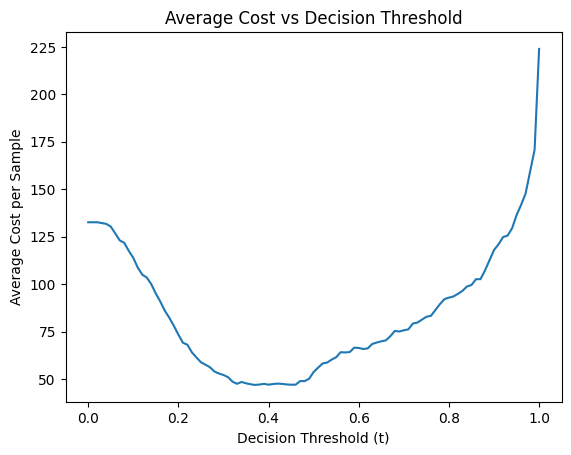

In [21]:
# Part 1: 3 points
# Implement the following function that calculates the average cost per sample of a binary classifier
# according to the specification in the problem statement.
# See the comments inside the function for details of the parameters.
import numpy as np
import matplotlib.pyplot as plt

def problem2_avg_cost(y_true, y_pred_proba, threshold):
    # Convert predicted probabilities into 0/1 labels
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Confusion matrix cases
    true_positives = (y_true == 1) & (y_pred == 1)
    true_negatives = (y_true == 0) & (y_pred == 0)
    false_positives = (y_true == 0) & (y_pred == 1)
    false_negatives = (y_true == 1) & (y_pred == 0)

    # Apply costs:
    # TP = 80, TN = 0, FP = 150, FN = 900
    costs = (
        true_positives.astype(float) * 80.0
        + true_negatives.astype(float) * 0.0
        + false_positives.astype(float) * 150.0
        + false_negatives.astype(float) * 900.0
    )

    # Average cost per sample
    avg_cost = np.mean(costs)

    return float(avg_cost)


# Thresholds from 0 to 1 with step size 0.01
thresholds = np.arange(0, 1.01, 0.01)

# Calculate cost for each threshold
costs = [
    problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, t)
    for t in thresholds
]

# Plot threshold vs average cost
plt.plot(thresholds, costs)
plt.xlabel("Decision Threshold (t)")
plt.ylabel("Average Cost per Sample")
plt.title("Average Cost vs Decision Threshold")
plt.show()

In [23]:
# Part 2: 2.5 points

# Use the cost function you implemented above to find the threshold that minimizes the average cost
# on the validation data (PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val).
# Store the optimal threshold in the variable below.

import numpy as np
from sklearn.metrics import precision_score, recall_score

# Find index of the smallest cost
min_cost_index = np.argmin(costs)

# Best threshold = threshold where cost is minimum
problem2_threshold = float(thresholds[min_cost_index])

# Minimum average cost on validation data
problem2_cost_val = float(costs[min_cost_index])

# Predicted labels using the best cost threshold
problem2_y_pred_val = (PROBLEM2_y_pred_proba_val >= problem2_threshold).astype(int)

# Precision and recall treating class 1 as the positive class
problem2_precision_1 = precision_score(
    PROBLEM2_y_true_val,
    problem2_y_pred_val,
    pos_label=1,
    zero_division=0
)

problem2_recall_1 = recall_score(
    PROBLEM2_y_true_val,
    problem2_y_pred_val,
    pos_label=1,
    zero_division=0
)

# Precision and recall treating class 0 as the positive class
problem2_precision_0 = precision_score(
    PROBLEM2_y_true_val,
    problem2_y_pred_val,
    pos_label=0,
    zero_division=0
)

problem2_recall_0 = recall_score(
    PROBLEM2_y_true_val,
    problem2_y_pred_val,
    pos_label=0,
    zero_division=0
)

print("Cost-optimal threshold:", problem2_threshold)
print("Validation average cost:", problem2_cost_val)
print("Precision class 1:", problem2_precision_1)
print("Recall class 1:", problem2_recall_1)
print("Precision class 0:", problem2_precision_0)
print("Recall class 0:", problem2_recall_0)

Cost-optimal threshold: 0.37
Validation average cost: 46.84507042253521
Precision class 1: 0.7738853503184714
Recall class 1: 0.9169811320754717
Precision class 0: 0.9707057256990679
Recall class 0: 0.91125


In [25]:
# Part 3: 2.5 points

# Find the threshold that **maximizes accuracy** on the validation data
# (equivalently, minimizes the 0-1 loss).
# Use the validation arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# Store the accuracy-optimal threshold in the variable below.
accuracies = [accuracy_score(PROBLEM2_y_true_val, (PROBLEM2_y_pred_proba_val >= t).astype(int)) for t in thresholds]
max_accuracy_index = np.argmax(accuracies)

problem2_threshold_acc = thresholds[max_accuracy_index]  # A float between 0 and 1

cost_at_acc_threshold = problem2_avg_cost(PROBLEM2_y_true_val, PROBLEM2_y_pred_proba_val, problem2_threshold)

# Calculate the difference in average cost between:
#   cost at accuracy-optimal threshold (this part) minus cost at cost-optimal threshold (part 2).
# That is: problem2_avg_cost(..., problem2_threshold_acc) - problem2_avg_cost(..., problem2_threshold)
problem2_cost_difference = cost_at_acc_threshold - problem2_cost_val  # A float

In [24]:
# Part 3: 2.5 points

# Find the threshold that **maximizes accuracy** on the validation data
# (equivalently, minimizes the 0-1 loss).
# Use the validation arrays PROBLEM2_y_true_val and PROBLEM2_y_pred_proba_val.
# Store the accuracy-optimal threshold in the variable below.
from sklearn.metrics import accuracy_score
import numpy as np

# Calculate accuracy for every threshold
accuracies = [
    accuracy_score(
        PROBLEM2_y_true_val,
        (PROBLEM2_y_pred_proba_val >= t).astype(int)
    )
    for t in thresholds
]

# Find the threshold with maximum accuracy
max_accuracy_index = np.argmax(accuracies)

problem2_threshold_acc = float(thresholds[max_accuracy_index])

# Calculate cost at the accuracy-optimal threshold
cost_at_acc_threshold = problem2_avg_cost(
    PROBLEM2_y_true_val,
    PROBLEM2_y_pred_proba_val,
    problem2_threshold_acc
)

# Difference in cost:
# cost at accuracy-optimal threshold minus cost at cost-optimal threshold
problem2_cost_difference = float(cost_at_acc_threshold - problem2_cost_val)

print("Accuracy-optimal threshold:", problem2_threshold_acc)
print("Accuracy at this threshold:", accuracies[max_accuracy_index])
print("Cost at accuracy-optimal threshold:", cost_at_acc_threshold)
print("Cost at cost-optimal threshold:", problem2_cost_val)
print("Cost difference:", problem2_cost_difference)

Accuracy-optimal threshold: 0.45
Accuracy at this threshold: 0.9286384976525821
Cost at accuracy-optimal threshold: 46.967136150234744
Cost at cost-optimal threshold: 46.84507042253521
Cost difference: 0.12206572769953539


In [26]:
# Part 4

import numpy as np

# Use cost-optimal threshold from Part 2 on TEST probabilities
y_pred_test = (PROBLEM2_y_pred_proba_test >= problem2_threshold).astype(int)

# Compute individual cost for each test sample
individual_costs = np.zeros(len(PROBLEM2_y_true_test))

for i in range(len(PROBLEM2_y_true_test)):
    y_true_i = PROBLEM2_y_true_test[i]
    y_pred_i = y_pred_test[i]

    if y_true_i == 1 and y_pred_i == 1:
        individual_costs[i] = 80      # True Positive
    elif y_true_i == 0 and y_pred_i == 0:
        individual_costs[i] = 0       # True Negative
    elif y_true_i == 0 and y_pred_i == 1:
        individual_costs[i] = 150     # False Positive
    elif y_true_i == 1 and y_pred_i == 0:
        individual_costs[i] = 900     # False Negative

# Average test cost
avg_test_cost = np.mean(individual_costs)

# Hoeffding's inequality
N_test = len(PROBLEM2_y_true_test)
R = 900 - 0
alpha = 0.05

epsilon = np.sqrt((-np.log(alpha / 2) * R**2) / (2 * N_test))

problem2_lower_bound = float(avg_test_cost - epsilon)
problem2_upper_bound = float(avg_test_cost + epsilon)

print("Average test cost:", avg_test_cost)
print("Epsilon:", epsilon)
print("Lower bound:", problem2_lower_bound)
print("Upper bound:", problem2_upper_bound)

Average test cost: 43.568075117370896
Epsilon: 37.454149483552364
Lower bound: 6.113925633818532
Upper bound: 81.02222460092327


In [ ]:
# Part 4: 4 points

# Using the cost-optimal threshold from part 2 (problem2_threshold), apply Hoeffding's inequality
# to provide a 95% confidence interval for the **average cost** on the test data.
# Use the test arrays PROBLEM2_y_true_test and PROBLEM2_y_pred_proba_test.
# Store the lower and upper bounds of the confidence interval in the variables below.

delta = 0.05       
a, b = 0.0, 1.0     
n = len(Y_valid)

epsilon = (b - a) * np.sqrt(np.log(2.0 / delta) / (2.0 * n))

ci_low  = max(a, val_cost - epsilon)
ci_high = min(b, val_cost + epsilon)

print("Optimal threshold:", optimal_threshold)
print("Validation average cost:", val_cost)
print("95% Hoeffding CI: [{:.6f}, {:.6f}]".format(ci_low, ci_high))
print("Half-width (epsilon):", epsilon)

problem2_cost_val = cost_at_optimal_threshold_valid
problem2_lower_bound = val_cost
problem2_upper_bound = (ci_low, ci_high)


## Free text answer

Put your explanation for part 4 below this line in this **cell**. Double-click to enter edit mode.

In particular, clearly state:
1. Why Hoeffding's inequality applies (or approximately applies) in this context.
2. What random variables are assumed i.i.d. and what their support is.
3. What bound you used for the per-sample cost range (i.e., $C_{\max} - C_{\min} = ?$ for this problem).

In [ ]:
Hoeffding’s inequality applies because we treat the test samples as independent observations and the per-sample costs are bounded. Each sample cost can only be 0, 80, 150, or 900, so the costs lie in the interval [0, 900]. Therefore the range is C_max - C_min = 900. Using the cost-optimal threshold from the validation set, I compute the average cost on the test set. For a 95% confidence interval, alpha = 0.05, and Hoeffding gives epsilon = sqrt((-log(alpha/2) * 900^2) / (2n)). The confidence interval is the empirical average test cost plus or minus epsilon.

---
## Exam vB, PROBLEM 3
Maximum Points = 14


A courier company monitors its trucks across four states:

*   **Downtown (D)**
*   **Suburbs (S)**
*   **Countryside (C)**
*   **Maintenance (M)** 

The transition probabilities between states at each time step are given by the matrix:

| Current State | D    | S    | C    | M    |
| ------------- | ---- | ---- | ---- | ---- |
| D             | 0.25 | 0.35 | 0.30 | 0.10 |
| S             | 0.20 | 0.40 | 0.30 | 0.10 |
| C             | 0.15 | 0.35 | 0.40 | 0.10 |
| M             | 0.00 | 0.00 | 0.00 | 1.00 |

1. If a truck starts in the **Suburbs**, what is the probability that it eventually ends up in **Maintenance**? [1p]
2. If a truck starts in **Downtown**, what is the probability that it will be in **Countryside** after five time steps? [2p]
3. Starting from **Downtown**, what is the expected number of steps before entering **Maintenance**? [3p] \
    **Hint**:
    To compute approximatively you could **simulate** but this gives a max score of [1.5p].
    To compute exactly use first-step analysis: 
$$
\text{Expected time from a state} = 1 + \sum_{\text{next states}} \big( \text{transition probability} \times \text{expected time from next state} \big)
$$

4. Is this Markov chain irreducible? Is it aperiodic? [2p]
5. Does this chain have a stationary distribution? If yes, compute it; if not, explain why. [2p]
6. Given that the truck starts in **Countryside** what is the probability that **the last state visited** before reaching **Maintenance** is **Suburbs**? [4p]  
**Hint**: To compute approximatively you could **simulate** but this gives a max score of [2p]. To compute exactly use first-step analysis: Let $f_D, f_S, f_C$ be the probabilities that the last state before hitting Maintenance is Suburbs, starting from Downtown, Suburbs, and Countryside respectively. Write recursive equations by conditioning on the next step. This gives a linear system to solve.


In [2]:
import numpy as np

P = np.array([
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

# transient states: D, S, C
Q = P[:3, :3]

# probabilities of going directly to Maintenance from D, S, C
r = P[:3, 3]

# solve absorption probabilities:
# h = Qh + r
# (I - Q)h = r
I = np.eye(3)

h = np.linalg.solve(I - Q, r)

# starting from Suburbs = index 1
problem3_prob_maintenance_from_suburbs = float(h[1])

print(h)
print(problem3_prob_maintenance_from_suburbs)
prob


[1. 1. 1.]
1.0000000000000004


NameError: name 'prob' is not defined

In [1]:
# Part 2

# Fill in the answer to part 2 below as a decimal number (float)
# If a truck starts in Downtown, what is the probability that it will be in Countryside after five time steps?
import numpy as np

P = np.array([
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

# Compute 5-step transition matrix
P5 = np.linalg.matrix_power(P, 5)

# Start Downtown = row 0
# End Countryside = column 2
problem3_prob_countryside_after_5_steps = float(P5[0, 2])

print(P5)
print(problem3_prob_countryside_after_5_steps)

[[0.12591719 0.24314281 0.22143    0.40951   ]
 [0.12591687 0.24314313 0.22143    0.40951   ]
 [0.12590719 0.24314281 0.22144    0.40951   ]
 [0.         0.         0.         1.        ]]
0.22143


In [3]:
# Part 3

# Fill in the answer to part 3 below as a decimal number (float)
# Starting from Downtown, what is the expected number of steps before entering Maintenance?
import numpy as np

P = np.array([
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

# Only use non-maintenance states: D, S, C
Q = P[:3, :3]

# Solve (I - Q)t = 1
I = np.eye(3)
ones = np.ones(3)

expected_steps = np.linalg.solve(I - Q, ones)

# Starting from Downtown = index 0
problem3_expected_steps_downtown = float(expected_steps[0])

print(expected_steps)
print(problem3_expected_steps_downtown)

[10. 10. 10.]
10.000000000000002


In [ ]:
# Part 4

# Fill in the answers to part 4 below as booleans (use True or False)
# Is this Markov chain irreducible? Is it aperiodic?
problem3_is_irreducible = True
problem3_is_aperiodic = False

In [ ]:
# this for stationaryy distribution code for my understanding part 5
P = np.array([   
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

pi = np.array([0.0, 0.0, 0.0, 1.0])

print(pi @ P)

[0. 0. 0. 1.]


In [4]:
# Part 5

# Fill in the answer to part 5 below (if it exists)
# The answer should be a numpy array of length 4 whose entries sum to 1.
# If it does not exist, write None instead of an array.
import numpy as np

problem3_stationary_distribution = np.array([0.0, 0.0, 0.0, 1.0])

print(problem3_stationary_distribution)

[0. 0. 0. 1.]



## Free text answer (Part 5)

Briefly explain **why** the chain **does** / **does not** have a stationary distribution.

Guidance:
- If you say it **has** one, why?.
- If you say it **does not**, explain what property fails.

Write your explanation below this line.

In [ ]:
Yes, the chain has a stationary distribution. Since Maintenance is an absorbing state and the other states can eventually reach Maintenance, the long-run probability is concentrated entirely on Maintenance. Therefore the stationary distribution is [0, 0, 0, 1].

In [6]:
import numpy as np

P = np.array([
    [0.25, 0.35, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
    [0.15, 0.35, 0.40, 0.10],
    [0.00, 0.00, 0.00, 1.00]
])

# Non-maintenance states: D, S, C
Q = P[:3, :3]

I = np.eye(3)

# Direct transition to Maintenance:
# D -> M means last state was D, not S => fail = 0
# S -> M means last state was S => success = 1
# C -> M means last state was C, not S => fail = 0
#
# Since probability of S -> M is 0.10, b = [0, 0.10, 0]
b = np.array([0.0, 0.10, 0.0])

# Solve (I - Q)f = b
f = np.linalg.solve(I - Q, b)

# Starting from Countryside = index 2
problem3_prob_last_before_maintenance_suburbs = float(f[2])

print(f)
print(problem3_prob_last_before_maintenance_suburbs)

[0.36842105 0.47368421 0.36842105]
0.36842105263157915


In [ ]:
# Part 6

# Fill in the answer to part 6 below as a decimal number (float)
# Given that the truck starts in Countryside, what is the probability that the last state visited before reaching Maintenance is Suburbs?
problem3_prob_last_suburbs_from_countryside = 0.035